# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 846 | Val: 205 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-18] Epoch   1/100 | LR: 3.88e-04 | train loss 1.1353 acc 0.508 | val loss 0.8255 acc 0.610 *


[ResNet-18] Epoch   2/100 | LR: 3.88e-04 | train loss 0.7122 acc 0.688 | val loss 0.5663 acc 0.751 *


[ResNet-18] Epoch   3/100 | LR: 3.88e-04 | train loss 0.5784 acc 0.743 | val loss 1.5202 acc 0.483


[ResNet-18] Epoch   4/100 | LR: 3.88e-04 | train loss 0.5591 acc 0.713 | val loss 0.9292 acc 0.595


...

[ResNet-18] Epoch  22/100 | LR: 3.88e-05 | train loss 0.1177 acc 0.931 | val loss 0.3879 acc 0.849


[ResNet-18] Epoch  23/100 | LR: 3.88e-05 | train loss 0.1005 acc 0.953 | val loss 0.3807 acc 0.859


[ResNet-18] Epoch  24/100 | LR: 3.88e-06 | train loss 0.0967 acc 0.946 | val loss 0.3897 acc 0.859


[ResNet-18] Epoch  25/100 | LR: 3.88e-06 | train loss 0.0990 acc 0.943 | val loss 0.3988 acc 0.854


[ResNet-18] Epoch  26/100 | LR: 3.88e-06 | train loss 0.0970 acc 0.953 | val loss 0.3979 acc 0.868

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 26.

[ResNet-18] Restored best checkpoint (val loss = 0.3662)


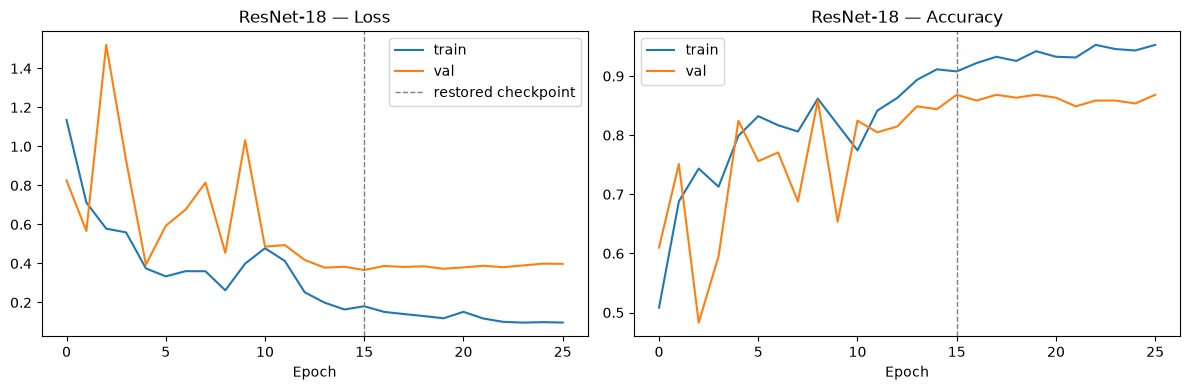

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.602


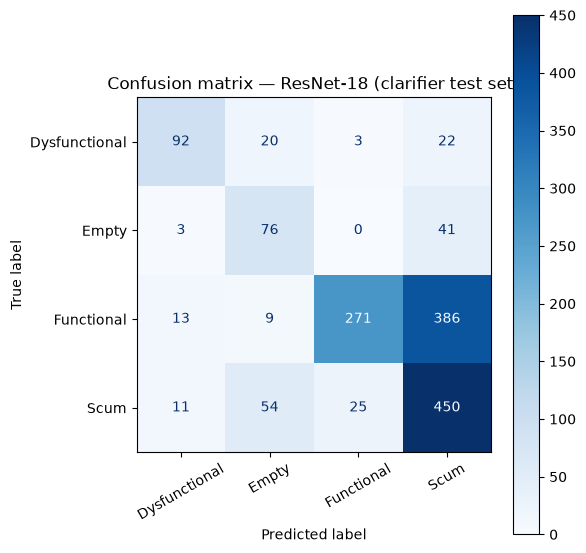

               precision    recall  f1-score   support

Dysfunctional      0.773     0.672     0.719       137
        Empty      0.478     0.633     0.545       120
   Functional      0.906     0.399     0.554       679
         Scum      0.501     0.833     0.625       540

     accuracy                          0.602      1476
    macro avg      0.665     0.634     0.611      1476
 weighted avg      0.711     0.602     0.595      1476



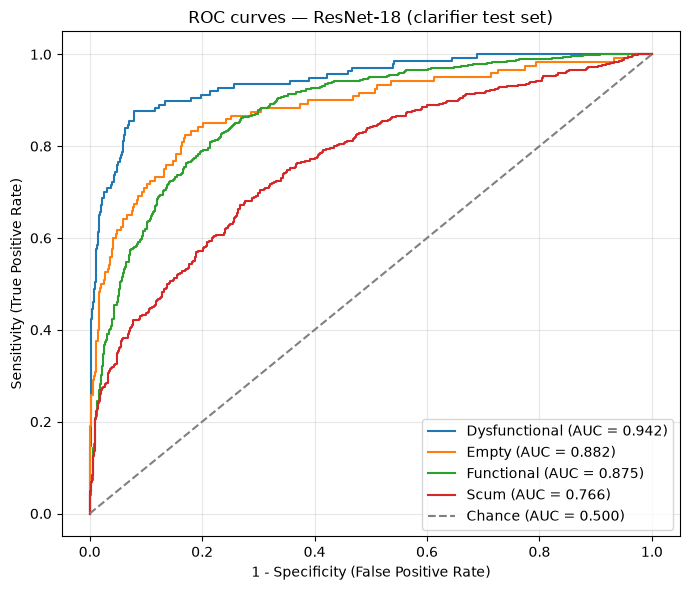

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.942
  Empty          : 0.882
  Functional     : 0.875
  Scum           : 0.766

Mean AUC (over 4/4 classes with test examples): 0.866


(np.float64(0.6023035230352304),
 {'Dysfunctional': 0.942385373113174,
  'Empty': 0.8817539331366764,
  'Functional': 0.8749175387083005,
  'Scum': 0.766130500158278})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/clarifier_aug/results_clarifier_resnet18_CapeFlats.pkl
Saved model weights to ../models/clarifier_resnet18_cnn.pt
